In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
dr=pd.read_csv('10.drug200.csv')

In [3]:
dr.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [4]:
dr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [5]:
dr.isna().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [6]:
dr['Drug'].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [7]:
dr['Drug'].unique()

array(['DrugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object)

In [8]:
dr['BP'].unique()

array(['HIGH', 'LOW', 'NORMAL'], dtype=object)

In [9]:
dr.describe() #stastical analysis

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [10]:
dr.describe(include='object')

,Sex,BP,Cholesterol,Drug
count,200,200,200,200
unique,2,3,2,5
top,M,HIGH,HIGH,DrugY
freq,104,77,103,91


In [11]:
dr.duplicated().sum()

0

<Axes: xlabel='Sex', ylabel='count'>

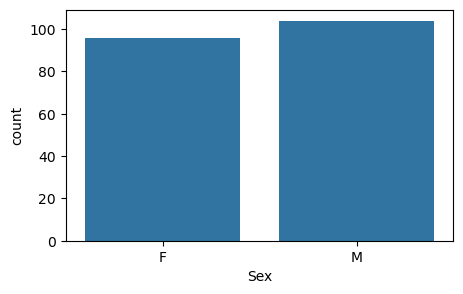

In [12]:
#eda
plt.figure(figsize=(5,3))
sns.countplot(data=dr,x='Sex')

<Axes: ylabel='count'>

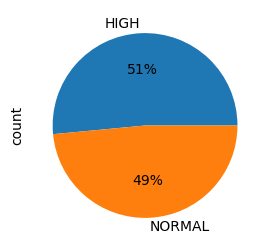

In [13]:
plt.figure(figsize=(5,3))
dr['Cholesterol'].value_counts().plot(kind='pie',autopct='%.0f%%')


<Axes: ylabel='count'>

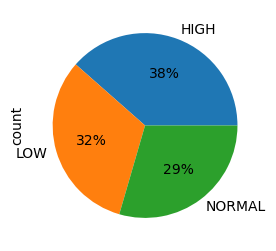

In [14]:
plt.figure(figsize=(5,3))
dr['BP'].value_counts().plot(kind='pie',autopct='%.0f%%')


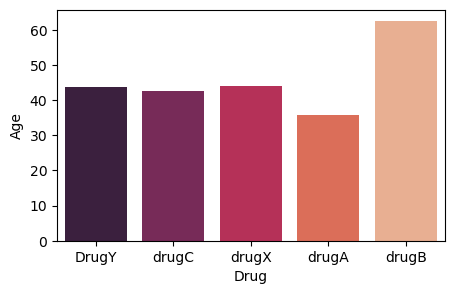

In [15]:
plt.figure(figsize=(5,3))
sns.barplot(x= dr.Drug,y=dr.Age,palette='rocket',ci=False)
plt.show()

<Axes: xlabel='Drug', ylabel='count'>

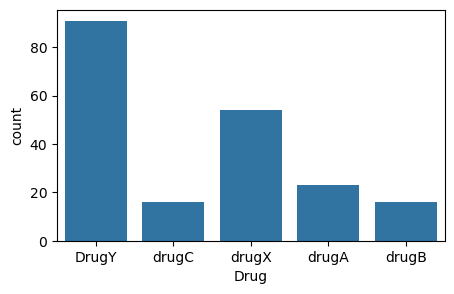

In [16]:
plt.figure(figsize=(5,3))
sns.countplot(x=dr.Drug)

In [17]:
#crosstab:to summarise categorical data and categorical data analzing relationship b/w variables
pd.crosstab(dr.Drug,dr.Sex)

Sex,F,M
Drug,,
DrugY,47,44
drugA,9,14
drugB,6,10
drugC,7,9
drugX,27,27


In [18]:
pd.crosstab(dr.BP,dr.Drug)

Drug,DrugY,drugA,drugB,drugC,drugX
BP,,,,,
HIGH,38,23,16,0,0
LOW,30,0,0,16,18
NORMAL,23,0,0,0,36


In [19]:
dr.dtypes

Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

In [20]:
dr=pd.get_dummies(dr,columns=['Sex','BP','Cholesterol'])
dr.head()

,Age,Na_to_K,Drug,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
0,23,25.355,DrugY,True,False,True,False,False,True,False
1,47,13.093,drugC,False,True,False,True,False,True,False
2,47,10.114,drugC,False,True,False,True,False,True,False
3,28,7.798,drugX,True,False,False,False,True,True,False
4,61,18.043,DrugY,True,False,False,True,False,True,False


In [21]:
dr.dtypes

Age                     int64
Na_to_K               float64
Drug                   object
Sex_F                    bool
Sex_M                    bool
BP_HIGH                  bool
BP_LOW                   bool
BP_NORMAL                bool
Cholesterol_HIGH         bool
Cholesterol_NORMAL       bool
dtype: object

In [22]:
x=dr.drop(['Drug'],axis=1)

In [23]:
y=dr['Drug']

In [24]:
x.head()

,Age,Na_to_K,Sex_F,Sex_M,BP_HIGH,BP_LOW,BP_NORMAL,Cholesterol_HIGH,Cholesterol_NORMAL
0,23,25.355,True,False,True,False,False,True,False
1,47,13.093,False,True,False,True,False,True,False
2,47,10.114,False,True,False,True,False,True,False
3,28,7.798,True,False,False,False,True,True,False
4,61,18.043,True,False,False,True,False,True,False


In [25]:
y.head()

0    DrugY
1    drugC
2    drugC
3    drugX
4    DrugY
Name: Drug, dtype: object

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
sc=StandardScaler()

In [28]:
xs=sc.fit_transform(x)

In [29]:
from sklearn.model_selection import train_test_split


In [30]:
x_train,x_test,y_train,y_test=train_test_split(xs,y,random_state=0,test_size=0.3)

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
m=LogisticRegression()

In [33]:
m.fit(x_train,y_train)

LogisticRegression()

In [34]:
y_pred_test=m.predict(x_test)

In [35]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay


In [36]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

       DrugY       1.00      0.97      0.98        30
       drugA       1.00      1.00      1.00         5
       drugB       0.75      1.00      0.86         3
       drugC       1.00      1.00      1.00         4
       drugX       1.00      1.00      1.00        18

    accuracy                           0.98        60
   macro avg       0.95      0.99      0.97        60
weighted avg       0.99      0.98      0.98        60



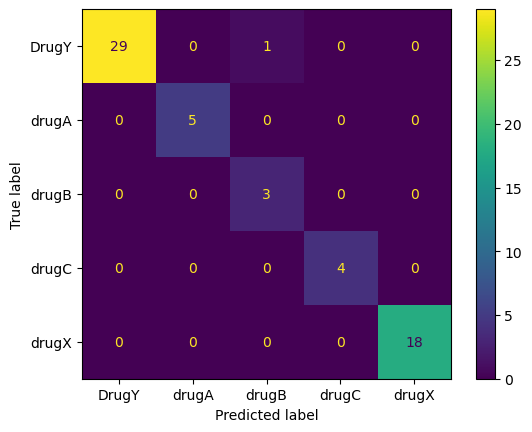

In [37]:
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test))

In [38]:
def predict(input_data):
    input_df=pd.DataFrame([input_data],columns=['Age','Sex','BP','Cholesterol','Na_to_K'])#2
    input_df=pd.get_dummies(input_df,columns=['Sex','BP','Cholesterol'])#3
    #ensure all col are present
    for i in x.columns:# in thier any columns is missing(encoding)v alues and fill with 0 #4
        if i not in input_df:
            input_df[i]=0
    #reorder
    input_df=input_df[x.columns]#5
    scale=sc.transform(input_df)#6
    pred=m.predict(scale)#7

    return pred #
sampledata=[23,'F','HIGH','HIGH',25.355] #1
print(predict(sampledata))

['DrugY']


# Imbalnced Dataset

## oversampling

In [82]:
y.value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [84]:
from imblearn.over_sampling import SMOTE

In [86]:
smote=SMOTE(random_state=0)

In [88]:
xs_os,y_os=smote.fit_resample(xs,y)

In [90]:
y_os.value_counts()

Drug
DrugY    91
drugC    91
drugX    91
drugA    91
drugB    91
Name: count, dtype: int64

In [96]:
xs_os

array([[-1.29159102,  1.28652212,  1.040833  , ..., -0.64686916,
         0.97043679, -0.97043679],
       [ 0.16269866, -0.4151454 , -0.96076892, ..., -0.64686916,
         0.97043679, -0.97043679],
       [ 0.16269866, -0.82855818, -0.96076892, ..., -0.64686916,
         0.97043679, -0.97043679],
       ...,
       [ 0.76088256, -1.104153  ,  1.040833  , ..., -0.64686916,
        -1.03046381,  1.03046381],
       [-0.1595796 , -0.7700231 , -0.96076892, ..., -0.64686916,
        -1.03046381,  1.03046381],
       [-0.52815733, -0.89539462,  1.040833  , ...,  1.54590766,
        -1.03046381,  1.03046381]])

In [102]:
x_train1,x_test1,y_train1,y_test1=train_test_split(xs_os,y_os,random_state=0,test_size=0.3)

In [106]:
model1=LogisticRegression()

In [110]:
model1.fit(x_train1,y_train1)

LogisticRegression()

In [112]:
y_pred_test1=model1.predict(x_test1)

In [120]:
print(classification_report(y_test1,y_pred_test1))

              precision    recall  f1-score   support

       DrugY       1.00      0.90      0.95        31
       drugA       0.96      1.00      0.98        27
       drugB       0.96      1.00      0.98        27
       drugC       0.96      1.00      0.98        27
       drugX       1.00      1.00      1.00        25

    accuracy                           0.98       137
   macro avg       0.98      0.98      0.98       137
weighted avg       0.98      0.98      0.98       137



## undersampling

In [123]:
from imblearn.under_sampling import RandomUnderSampler

In [125]:
un=RandomUnderSampler(random_state=0)

In [127]:
x_us,y_us=un.fit_resample(xs,y)

In [129]:
y_us.value_counts()

Drug
DrugY    16
drugA    16
drugB    16
drugC    16
drugX    16
Name: count, dtype: int64

In [133]:
x_train2,x_test2,y_train2,y_test2=train_test_split(x_us,y_us,random_state=0,test_size=0.3)

In [135]:
model2=LogisticRegression()

In [137]:
model2.fit(x_train2,y_train2)

LogisticRegression()

In [139]:
y_pred_test2=model2.predict(x_test2)

In [143]:
print(classification_report(y_test2,y_pred_test2))

              precision    recall  f1-score   support

       DrugY       0.50      0.33      0.40         3
       drugA       0.80      1.00      0.89         4
       drugB       1.00      1.00      1.00         6
       drugC       1.00      1.00      1.00         4
       drugX       0.86      0.86      0.86         7

    accuracy                           0.88        24
   macro avg       0.83      0.84      0.83        24
weighted avg       0.86      0.88      0.86        24

